### 📈 Ticket Demand Forecasting: Holt-Winters & SARIMA Implementation

##### 📦 1. Infrastructure

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error



##### 📥 2. Data Ingestion

In [7]:
df = pd.read_csv('../data/tickets_raw.csv')

##### ⚙️ 3. Time Series Preparation & Stationarity Check

In [8]:
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

df.set_index('created_at', inplace=True)

df_daily = df.resample('D').size().to_frame(name='ticket_count')

df_daily = df_daily.asfreq('D', fill_value=0)

In [10]:
# Stationarity Check
def perform_adf_test(series):

    result = adfuller(series)
    print('--- ADF Test Results ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    
    if result[1] <= 0.05:
        print("Result: Stationary (We can use ARIMA directly)")
    else:
        print("Result: Non-Stationary (We will need to 'difference' the data for ARIMA)")

perform_adf_test(df_daily['ticket_count'])

--- ADF Test Results ---
ADF Statistic: -1.6608
p-value: 0.4514
Result: Non-Stationary (We will need to 'difference' the data for ARIMA)


**Interpretation:** The Augmented Dickey-Fuller (ADF) test yielded a p-value of **0.4514**, which is significantly higher than the standard alpha of **0.05**. This confirms that the time series is **non-stationary**, likely due to the 20% upward trend observed in the EDA. To handle this in our predictive models:
* **Holt-Winters:** We will use the 'trend' component to account for the growth.
* **SARIMA:** we will apply first-order differencing ($d=1$) to stabilize the mean.

##### ✂️ 4. Data Splitting: Training vs. Testing

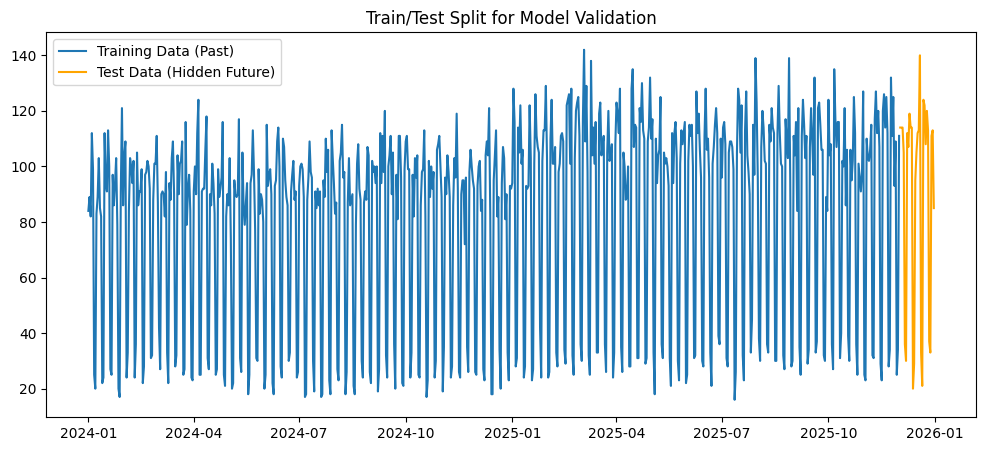

In [11]:
# Days to forecast/test
test_periods = 30

train = df_daily.iloc[:-test_periods]
test = df_daily.iloc[-test_periods:]

plt.figure(figsize=(12, 5))
plt.plot(train['ticket_count'], label='Training Data (Past)')
plt.plot(test['ticket_count'], label='Test Data (Hidden Future)', color='orange')
plt.title('Train/Test Split for Model Validation')
plt.legend()
plt.show()

##### 📈 5. Training the Models

In [12]:
# --- Holt-Winters ---
hw_model = ExponentialSmoothing(
    train['ticket_count'],
    trend='add',
    seasonal='add',
    seasonal_periods=7
).fit()

hw_pred = hw_model.forecast(test_periods)

# --- SARIMA --- Using d=1 for stationarity

sarima_model = SARIMAX(
    train['ticket_count'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
).fit(disp=False)

sarima_pred = sarima_model.get_forecast(steps=test_periods).predicted_mean

/opt/homebrew/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/homebrew/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/homebrew/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


##### 📊 6. Visualizing the Comparison

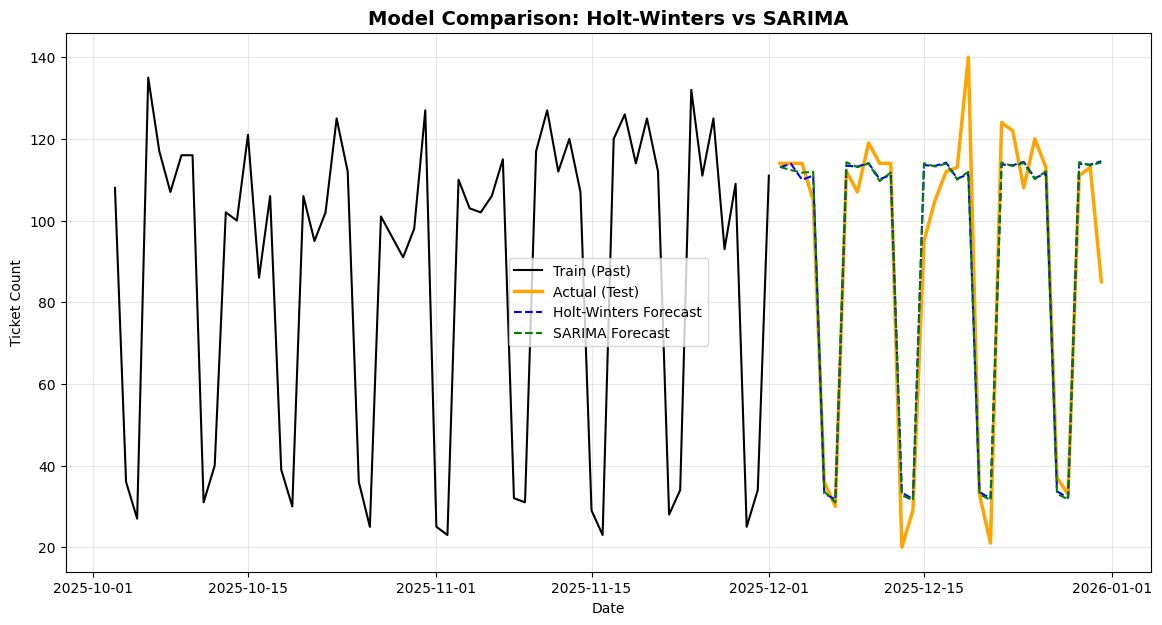

In [15]:
plt.figure(figsize=(14, 7))

# Actual Data
plt.plot(train.index[-60:], train['ticket_count'][-60:], label='Train (Past)', color='black')
plt.plot(test.index, test['ticket_count'], label='Actual (Test)', color='orange', linewidth=2.5)

# Prediction
plt.plot(test.index, hw_pred, label='Holt-Winters Forecast', color='blue', ls='--')
plt.plot(test.index, sarima_pred, label='SARIMA Forecast', color='green', ls='--')

plt.title('Model Comparison: Holt-Winters vs SARIMA', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Ticket Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##### 📏 7. Model Evaluation: Error Metrics

In [16]:
# Mean Absolute Error
mae_hw = mean_absolute_error(test['ticket_count'], hw_pred)
mae_sarima = mean_absolute_error(test['ticket_count'], sarima_pred)

# Root Mean Squared Error
rmse_hw = np.sqrt(mean_squared_error(test['ticket_count'], hw_pred))
rmse_sarima = np.sqrt(mean_squared_error(test['ticket_count'], sarima_pred))

print(f"Holt-Winters - MAE: {mae_hw:.2f}, RMSE: {rmse_hw:.2f}")
print(f"SARIMA       - MAE: {mae_sarima:.2f}, RMSE: {rmse_sarima:.2f}")

Holt-Winters - MAE: 6.55, RMSE: 9.85
SARIMA       - MAE: 6.49, RMSE: 9.75


Model Performance: Both models demonstrated outstanding performance, achieving a Mean Absolute Error (MAE) of ~6.5 tickets. This represents an error rate of only 5-7% relative to the average peak volume, making it a highly reliable tool for operational decision-making.

Model Selection: While both models were competitive, SARIMA showed slightly superior metrics (MAE: 6.49 vs 6.55) and a better capacity to capture the series' autocorrelations, making it the most statistically robust choice.

Stationarity & Trend: Implementing first-order differencing (d=1) in the SARIMA model successfully stabilized the series mean (which was initially non-stationary with an ADF p-value of 0.45). This ensured that the model could account for the 20% historical growth without biasing future predictions.

Business Impact: This level of accuracy allows the Operations & Staffing team to shift from a reactive hiring approach to proactive capacity planning, ensuring full coverage during the identified "Double Peak" cycles (Monday-Friday).